# Delamanid ablation comparison

Compares four stability-selection runs on CMM-logistic, all with `max_parents=4`, `k_max=6`, `min_cluster_count=4`, 100 runs at 80% subsample. The four conditions differ only in which population-structure covariates are included or restricted:

1. `baseline`: variants only, no lineage, no clinical type
2. `with_lineage`: adds `lineage_2`, `lineage_4` (other lineages merged below 5 samples)
3. `with_lineage_and_type`: also adds `type_beyond_MDR` (selection-history proxy)
4. `with_lineage_forbid_to_mic`: lineage included but lineage to MIC edges forbidden

Goal: see which variant to MIC associations survive population-structure adjustment, and identify lineage-independent biomarker candidates for delamanid resistance.

In [2]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parents[2]))

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RESULTS = Path.cwd().parents[2] / 'results' / 'subsampling' / 'tb_subsampling_dlm_mp4_k6_mcc4'
CONDITIONS = ['baseline', 'with_lineage', 'with_lineage_and_type', 'with_lineage_forbid_to_mic']
SHORT = {'baseline': 'baseline', 'with_lineage': '+lineage', 'with_lineage_and_type': '+lineage+type', 'with_lineage_forbid_to_mic': 'forbid lin->MIC'}

edges = {c: pd.read_csv(RESULTS / c / 'edge_stability.csv') for c in CONDITIONS}
kdist = {c: pd.read_csv(RESULTS / c / 'per_node_k.csv') for c in CONDITIONS}

## MIC cluster count is stable at k=6

The mode number of mixture components for `dlm_mic` stays at 6 across all four conditions, with k=6 selected in 43 to 50 percent of runs. Adding more parents (type) or restricting edges (forbid) slightly lowers the k=6 share.

In [3]:
rows = []
for c in CONDITIONS:
    row = kdist[c][kdist[c]['feature'] == 'dlm_mic'].iloc[0]
    rows.append({'condition': SHORT[c], 'mode_k': int(row['mode_k']), 'k=6 share': int(row['k6_count']) / 100, 'mean_k': round(float(row['mean_k']), 2)})
pd.DataFrame(rows)

,condition,mode_k,k=6 share,mean_k
0,baseline,6,0.49,5.35
1,+lineage,6,0.50,5.31
2,+lineage+type,6,0.45,5.21
3,forbid lin->MIC,6,0.43,5.22


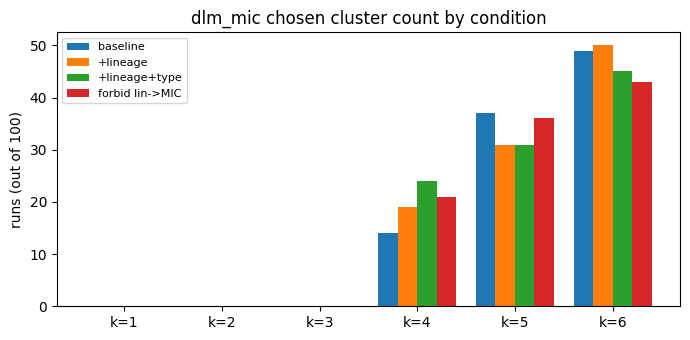

In [5]:
fig, ax = plt.subplots(figsize=(7, 3.5))
k_cols_template = ['k1_count', 'k2_count', 'k3_count', 'k4_count', 'k5_count', 'k6_count']
x = np.arange(6)
width = 0.2
for i, c in enumerate(CONDITIONS):
    row = kdist[c][kdist[c]['feature'] == 'dlm_mic'].iloc[0]
    counts = [int(row[col]) if col in row.index else 0 for col in k_cols_template]
    ax.bar(x + i * width, counts, width, label=SHORT[c])
ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(['k=1', 'k=2', 'k=3', 'k=4', 'k=5', 'k=6'])
ax.set_ylabel('runs (out of 100)')
ax.set_title('dlm_mic chosen cluster count by condition')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Variant to MIC frequencies across conditions

Each row is a candidate biomarker. The columns track how often the edge `variant -> dlm_mic` was selected across the 100 subsamples in each condition.

The interpretation question: does the variant survive adjustment for lineage, or does its baseline signal flow through population structure?

In [6]:
MIN_ELIGIBLE = 50

def freq_to_mic(df, source):
    sub = df[(df['target'] == 'dlm_mic') & (df['source'] == source) & (df['n_eligible'] >= MIN_ELIGIBLE)]
    return float(sub['frequency'].iloc[0]) if len(sub) else 0.0

variants = sorted({s for c in CONDITIONS for s in edges[c]['source'].unique()} - {'lineage_2', 'lineage_4', 'type_beyond_MDR', 'fgd1_Lys270Met'})
table = pd.DataFrame({SHORT[c]: [freq_to_mic(edges[c], v) for v in variants] for c in CONDITIONS}, index=variants)
table = table.sort_values(SHORT['with_lineage_forbid_to_mic'], ascending=False)
table.round(2)

,baseline,+lineage,+lineage+type,forbid lin->MIC
pepq_Ala87Gly,0.27,0.51,0.41,0.61
mmpl5_Asp767Asn,0.38,0.08,0.06,0.35
rv1979c_C*135G,0.55,0.39,0.37,0.33
rv0678_G*128C,0.30,0.06,0.19,0.26
mmpl5_Thr794Ile,0.14,0.02,0.00,0.11
fgd1_G*357C,0.17,0.05,0.09,0.07
mmpl5_Ile948Val,0.00,0.01,0.00,0.00
fgd1_Phe320Phe,0.06,0.00,0.00,0.00


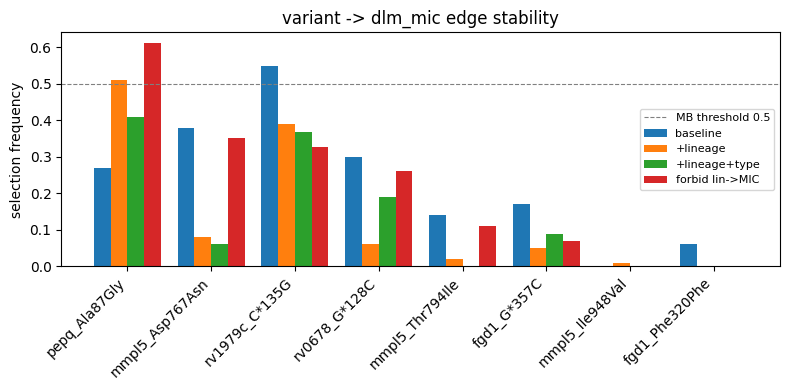

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(table))
width = 0.2
for i, c in enumerate(CONDITIONS):
    ax.bar(x + i * width, table[SHORT[c]].values, width, label=SHORT[c])
ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8, label='MB threshold 0.5')
ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(table.index, rotation=45, ha='right')
ax.set_ylabel('selection frequency')
ax.set_title('variant -> dlm_mic edge stability')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## pepq is the only variant that strengthens under lineage adjustment

Most variants drop sharply when lineage is added (rv1979c, mmpl5_Asp767Asn, rv0678, fgd1, mmpl5_Thr794Ile): their baseline MIC signal was largely flowing through population structure. `pepq_Ala87Gly` is the exception, roughly doubling from 0.27 to 0.51, and crossing 0.6 when lineage to MIC is forbidden.

This makes `pepq_Ala87Gly` the cleanest lineage-independent candidate in the panel. The caveat appears in the next section.

## Lineage absorbs co-variation between variants

In `baseline`, some variant-to-variant edges reflect lineage-driven statistical dependence (variants that co-occur because they share a lineage, or that anti-occur because they belong to different lineages) rather than direct causal links. Adding lineage redirects them to the real source.

Example: `mmpl5_Thr794Ile -> fgd1_Phe320Phe` was selected 78/100 in baseline. With lineage in, that edge vanishes and `lineage_4 -> mmpl5_Thr794Ile` and `lineage_4 -> fgd1_Phe320Phe` both saturate at 99/100. Both variants are lineage 4 markers.

Variant-to-variant edges that survive this adjustment are more credibly real.


In [6]:
df = edges['with_lineage']
lineage_out = df[df['source'].isin(['lineage_2', 'lineage_4']) & (df['n_eligible'] >= MIN_ELIGIBLE)].sort_values('frequency', ascending=False)
lineage_out[['source', 'target', 'frequency']].round(2).reset_index(drop=True)

,source,target,frequency
0,lineage_4,mmpl5_Thr794Ile,0.99
1,lineage_4,fgd1_Phe320Phe,0.99
2,lineage_2,mmpl5_Asp767Asn,0.95
3,lineage_2,rv0678_G*128C,0.84
4,lineage_2,dlm_mic,0.52
5,lineage_4,fgd1_G*357C,0.46
6,lineage_4,rv1979c_C*135G,0.45
7,lineage_2,rv1979c_C*135G,0.25
8,lineage_2,pepq_Ala87Gly,0.18
9,lineage_4,dlm_mic,0.12


## type_beyond_MDR points at pepq and at MIC

`type_beyond_MDR = 1` if the strain resists drugs beyond rifampicin + isoniazid (preXDR or XDR). 52 strains.

Edges:
- `type_beyond_MDR -> pepq_Ala87Gly`: 0.35
- `type_beyond_MDR -> dlm_mic`: 0.27

Concern: more-resistant strains get sequenced more deeply, so they're over-represented here. That makes type a collider between pepq and MIC, and conditioning on it can fake a pepq -> MIC link.


In [7]:
df = edges['with_lineage_and_type']
type_out = df[(df['source'] == 'type_beyond_MDR') & (df['n_eligible'] >= MIN_ELIGIBLE)].sort_values('frequency', ascending=False)
type_out[['source', 'target', 'count', 'n_eligible', 'frequency']].round(3).reset_index(drop=True)

,source,target,count,n_eligible,frequency
0,type_beyond_MDR,pepq_Ala87Gly,18,52,0.346
1,type_beyond_MDR,dlm_mic,14,52,0.269
2,type_beyond_MDR,rv1979c_C*135G,1,51,0.020
3,type_beyond_MDR,fgd1_G*357C,1,52,0.019


## Takeaways

**Decision rule.** `with_lineage` is the honest model (lineage to MIC is real, 0.12 to 0.55). `forbid_to_mic` is a stress test. A variant is credible only if its `variant -> MIC` frequency is stable across both.

**Candidates:**
1. **pepq_Ala87Gly: passes.** 0.51 in `with_lineage`, 0.61 in forbid. Only variant that strengthens under adjustment. Caveat: `type -> pepq = 0.35`, so the type collider path still needs to be ruled out by the `forbid_type_to_mic` run.
2. **rv1979c_C*135G: weak.** Drops monotonically (0.55 to 0.33). Partly lineage confounding, possibly a small residual effect.
3. **mmpl5_Asp767Asn: artifact.** 0.08 in `with_lineage`, 0.35 in forbid. It is a lineage_2 marker (`lineage_2 -> mmpl5_Asp767Asn = 0.95`), so forbidding lineage to MIC just reroutes lineage_2's signal through it. Cannot separate the two.

**Other:** k=6 is robust across all four conditions, k_max=6 validated.